# Assignment: What Drives the AI Model’s Predictions?

We will now explore a new AI-based multimodal model designed to predict type 2 diabetes (T2D) based on patient data.
The model receives information from three data types (modalities):
- Demographics (age, sex, BMI)
- Clinical measurements (HbA1c, blood pressure, HDL, triglycerides)
- Genetics (SNPs)
The goal is to understand:
- how the model works
- what drives its predictions
- whether we can trust its output


## Data
We begin by looking at the data used by the model.

- **Modality A** — demographics (age, sex, BMI)
- **Modality B** — clinical measurements (blood pressure, heart rate, SpO₂, HbA1c)
- **Modality C** — genotypes: dosage values (0 / 1 / 2) for 10 T2D-associated SNPs

In [1]:
import numpy as np       # For numerical operations and random number generation
import pandas as pd      # For creating and managing data tables
import warnings
import matplotlib.pyplot as plt

# Ignore the specific tight_layout warning
warnings.filterwarnings(
    "ignore", 
    message="This figure includes Axes that are not compatible with tight_layout"
)
# ── PARAMETERS (feel free to change these) ────────────────────────────────────

RANDOM_SEED  = 42    # Any whole number — ensures the same data every time you run

N_PATIENTS   = 200  # Total number of patients to simulate

# Proportion of patients in each diagnosis group (must sum to 1.0)
PROP_HEALTHY      = 0.60   # 60 % healthy
PROP_PREDIABETES  = 0.25   # 25 % pre-diabetes
PROP_DIABETES     = 0.15   # 15 % diabetes

# ─────────────────────────────────────────────────────────────────────────────
# Quick check: proportions must sum to 1
assert abs(PROP_HEALTHY + PROP_PREDIABETES + PROP_DIABETES - 1.0) < 1e-9, \
    "ERROR: The three proportions must sum to exactly 1.0"
np.random.seed(RANDOM_SEED)

# ── 1. Patient names ──────────────────────────────────────────────────────────
first_names = [
    "Alice", "Bob", "Carol", "David", "Emma", "Frank", "Grace", "Henry",
    "Isla", "James", "Karen", "Liam", "Mia", "Noah", "Olivia", "Peter",
    "Quinn", "Rachel", "Sam", "Tara", "Uma", "Victor", "Wendy", "Xander",
    "Yara", "Zoe", "Aaron", "Beth", "Chris", "Diana", "Evan", "Fiona",
    "George", "Hannah", "Ivan", "Julia", "Kevin", "Laura", "Mike", "Nina",
    "Oscar", "Paula", "Quentin", "Rose", "Steve", "Teresa", "Umar", "Vera",
    "Will", "Xena"
]
last_names = [
    "Smith", "Johnson", "Williams", "Brown", "Jones", "Garcia", "Miller",
    "Davis", "Wilson", "Taylor", "Anderson", "Thomas", "Jackson", "White",
    "Harris", "Martin", "Thompson", "Young", "Lee", "Walker", "Hall",
    "Allen", "King", "Wright", "Scott", "Green", "Baker", "Adams", "Nelson",
    "Hill", "Ramirez", "Campbell", "Mitchell", "Roberts", "Carter", "Evans",
    "Turner", "Phillips", "Parker", "Edwards", "Collins", "Stewart", "Morris",
    "Rogers", "Reed", "Cook", "Morgan", "Bell", "Murphy", "Bailey"
]

# Sample unique full names
first = np.random.choice(first_names, size=N_PATIENTS, replace=True)
last  = np.random.choice(last_names,  size=N_PATIENTS, replace=True)
names = [f"{f} {l}" for f, l in zip(first, last)]

# ── 2. Assign diagnosis labels ────────────────────────────────────────────────
labels = np.random.choice(
    ["Healthy", "Pre-diabetes", "Diabetes"],
    size=N_PATIENTS,
    p=[PROP_HEALTHY, PROP_PREDIABETES, PROP_DIABETES]
)

# ── 3. Generate HbA1c (mmol/mol) — drives the label ──────────────────────────
# Healthy: 20–38  |  Pre-diabetes: 39–47  |  Diabetes: 48–80
hba1c = np.array([
    np.random.randint(20, 39)  if lbl == "Healthy"      else
    np.random.randint(39, 48)  if lbl == "Pre-diabetes"  else
    np.random.randint(48, 81)
    for lbl in labels
])

# ── 4. Modality A features ────────────────────────────────────────────────────
# Age (years): slightly older in diabetes groups
age = np.array([
    np.random.randint(20, 66) if lbl == "Healthy"      else
    np.random.randint(30, 71) if lbl == "Pre-diabetes" else
    np.random.randint(35, 76)
    for lbl in labels
])

# Sex
sex = np.random.choice(["Male", "Female"], size=N_PATIENTS)

# BMI (kg/m²): higher in diabetes groups
bmi = np.array([
    round(np.random.uniform(18.5, 27.0), 1) if lbl == "Healthy"      else
    round(np.random.uniform(21, 27.0), 1) if lbl == "Pre-diabetes" else
    round(np.random.uniform(27.0, 40.0), 1)
    for lbl in labels
])

# ── 5. Modality B features ────────────────────────────────────────────────────
# Blood pressure: systolic 120–139 mmHg, diastolic 80–89 mmHg (two separate columns)
systolic  = np.random.randint(120, 140, size=N_PATIENTS)
diastolic = np.random.randint(80,  90,  size=N_PATIENTS)

# Heart rate (bpm): 60–90
heart_rate = np.random.randint(71, 91, size=N_PATIENTS)

# Oxygen saturation (%): 95.0–100.0
spo2 = np.round(np.random.uniform(96.5, 100.0, size=N_PATIENTS), 1)

# Triglycerides (mmol/L): progressively higher with metabolic deterioration
# Healthy: < 2.0  |  Pre-diabetes: ~1.5–2.5  |  T2D: ~2.0–4.5
triglycerides = np.array([
    round(np.random.uniform(0.5, 1.9), 2) if lbl == "Healthy"      else
    round(np.random.uniform(1.4, 2.6), 2) if lbl == "Pre-diabetes" else
    round(np.random.uniform(2.0, 4.5), 2)
    for lbl in labels
])

# HDL cholesterol (mmol/L): progressively lower with metabolic deterioration
# Thresholds are sex-dependent (Men: >1.0 normal; Women: >1.3 normal)
hdl = np.array([
    round(np.random.uniform(1.0, 1.9), 2) if (lbl == "Healthy"      and s == "Male")   else
    round(np.random.uniform(1.3, 2.1), 2) if (lbl == "Healthy"      and s == "Female") else
    round(np.random.uniform(0.9, 1.2), 2) if (lbl == "Pre-diabetes" and s == "Male")   else
    round(np.random.uniform(1.1, 1.4), 2) if (lbl == "Pre-diabetes" and s == "Female") else
    round(np.random.uniform(0.6, 1.0), 2) if (lbl == "Diabetes"     and s == "Male")   else
    round(np.random.uniform(0.7, 1.2), 2)                                                # Diabetes, Female
    for lbl, s in zip(labels, sex)
])

# ── 6. Assemble Modality A and B DataFrames ───────────────────────────────────
modality_A = pd.DataFrame({
    "Name"    : names,
    "Age"     : age,
    "Sex"     : sex,
    "BMI"     : bmi,
    "Label"   : labels,
})

modality_B = pd.DataFrame({
    "Name"                      : names,
    "Systolic BP (mmHg)"        : systolic,
    "Diastolic BP (mmHg)"       : diastolic,
    "Heart Rate (bpm)"          : heart_rate,
    "SpO2 (%)"                  : spo2,
    "HbA1c (mmol/mol)"          : hba1c,
    "Triglycerides (mmol/L)"    : triglycerides,
    "HDL Cholesterol (mmol/L)"  : hdl,
    "Label"                     : labels,
})

# ── 7. Modality C — Genotypes ─────────────────────────────────────────────────
# Ten T2D-associated SNPs encoded as dosage (0 / 1 / 2 copies of the risk allele).
# Generated INDEPENDENTLY of the diagnosis label — genotypes are noise for diagnosis.
# Minor allele frequencies (MAF) are drawn from realistic ranges per SNP.

t2d_risk_snps = [
    "rs7903146",   # TCF7L2   — strongest T2D GWAS hit
    "rs12255372",  # TCF7L2
    "rs9939609",   # FTO      — also linked to obesity
    "rs1801282",   # PPARG    — insulin sensitivity
    "rs13266634",  # SLC30A8  — β-cell zinc transporter
    "rs7754840",   # CDKAL1
    "rs10811661",  # CDKN2A/B — cell-cycle regulator
    "rs5219",      # KCNJ11   — β-cell potassium channel
    "rs2237892",   # KCNQ1
    "rs4402960",   # IGF2BP2
]

# Use a separate RNG seeded independently so genotypes do not interfere
# with the rest of the simulation
rng_geno = np.random.default_rng(RANDOM_SEED + 99)

# Realistic minor allele frequencies (approximately matching published values)
mafs = [0.30, 0.28, 0.43, 0.12, 0.32, 0.38, 0.18, 0.35, 0.40, 0.30]

snp_data = {}
for snp, maf in zip(t2d_risk_snps, mafs):
    p0 = (1 - maf) ** 2          # homozygous reference
    p1 = 2 * maf * (1 - maf)     # heterozygous
    p2 = maf ** 2                 # homozygous risk
    snp_data[snp] = rng_geno.choice([0, 1, 2], size=N_PATIENTS, p=[p0, p1, p2])

modality_C = pd.DataFrame(snp_data)
modality_C["Label"] = labels
modality_C.insert(0, "Name", names)

In [2]:
print("=== Modality A — Demographics (first 10 patients) ===")
modality_A.head(10)

=== Modality A — Demographics (first 10 patients) ===


,Name,Age,Sex,BMI,Label
0,Mike Harris,39,Male,21.6,Pre-diabetes
1,Chris Campbell,22,Female,20.6,Healthy
2,Olivia Campbell,60,Female,24.6,Healthy
3,Quentin Wright,64,Male,25.8,Healthy
4,Henry Collins,37,Female,25.6,Healthy
5,Uma Murphy,65,Female,23.4,Pre-diabetes
6,Mike Murphy,41,Male,24.2,Healthy
7,Sam Thomas,53,Female,20.2,Healthy
8,Wendy Parker,37,Female,22.8,Pre-diabetes
9,Karen Johnson,59,Female,26.1,Healthy


In [3]:
print("=== Modality B — Clinical Measurements (first 10 patients) ===")
modality_B.head(10)

=== Modality B — Clinical Measurements (first 10 patients) ===


,Name,Systolic BP (mmHg),Diastolic BP (mmHg),Heart Rate (bpm),SpO2 (%),HbA1c (mmol/mol),Triglycerides (mmol/L),HDL Cholesterol (mmol/L),Label
0,Mike Harris,139,84,87,97.3,39,2.41,1.02,Pre-diabetes
1,Chris Campbell,123,87,82,99.2,25,0.64,1.97,Healthy
2,Olivia Campbell,127,89,85,97.5,25,1.18,1.61,Healthy
3,Quentin Wright,139,82,85,99.4,31,0.71,1.51,Healthy
4,Henry Collins,138,83,76,98.0,32,0.95,1.77,Healthy
5,Uma Murphy,132,88,82,98.8,43,2.28,1.16,Pre-diabetes
6,Mike Murphy,133,86,90,96.8,35,1.17,1.33,Healthy
7,Sam Thomas,129,80,88,98.7,30,1.03,1.57,Healthy
8,Wendy Parker,130,83,84,98.1,43,1.87,1.11,Pre-diabetes
9,Karen Johnson,121,83,72,98.6,23,1.14,1.32,Healthy


In [4]:
print("=== Modality C — Genotypes (first 10 patients) ===")
modality_C.head(10)

=== Modality C — Genotypes (first 10 patients) ===


,Name,rs7903146,rs12255372,rs9939609,rs1801282,rs13266634,rs7754840,rs10811661,rs5219,rs2237892,rs4402960,Label
0,Mike Harris,1,0,1,0,1,1,1,2,1,1,Pre-diabetes
1,Chris Campbell,2,0,2,0,0,0,1,1,1,0,Healthy
2,Olivia Campbell,0,0,2,0,1,1,0,0,2,0,Healthy
3,Quentin Wright,0,0,1,0,0,1,0,1,1,0,Healthy
4,Henry Collins,1,1,0,0,1,0,0,0,0,1,Healthy
5,Uma Murphy,1,0,1,1,2,0,1,1,2,0,Pre-diabetes
6,Mike Murphy,0,0,1,0,1,1,2,0,1,1,Healthy
7,Sam Thomas,0,0,1,0,1,0,0,0,1,0,Healthy
8,Wendy Parker,1,1,2,0,0,1,0,2,2,0,Pre-diabetes
9,Karen Johnson,1,0,1,0,1,2,0,1,2,1,Healthy


## Questions:
- Which data in the table do you think are most important for making a diagnosis?
- What types of patients should be included in the dataset? (e.g., age, sex, different disease profiles)
Info
Data are often divided into three parts:
- Training set – used to teach the model patterns
- Validation set – used to tune the model
- Test set – used to test whether the model works on new patients it has not seen before


**Multimodal Model: What does this mean?**

This model combines several types of patient data — a so-called multimodal model.
We use three modalities:
- Modality A – Demographics: age, sex, BMI
- Modality B – Clinical measurements: HbA1c, blood pressure, HDL, triglycerides
- Modality C – Genetics: genetic variants (SNPs)

**Info**

A multimodal model can:
- combine different types of information
- provide a more complete picture of the patient
- potentially improve the model’s assessment

However:
Not all data types necessarily contribute positively — some may be less relevant or introduce noise.


## Now we run the model on the data.

We now investigate whether the model can identify patterns in the different modalities.
Here we examine whether there is structure in the data without knowing the diagnoses.

PCA – one dot per patient.

**Info**
- [PCA (**Principal Component Analysis**)](https://setosa.io/ev/principal-component-analysis/) is a method used to identify patterns in complex data and make the data easier to visualize and understand.
- It combines many variables into a few main patterns called principal components (PCs).
PC1 is the strongest pattern in the data, PC2 is the second strongest pattern, and so on.
- Brief intro to PCA: https://setosa.io/ev/principal-component-analysis/


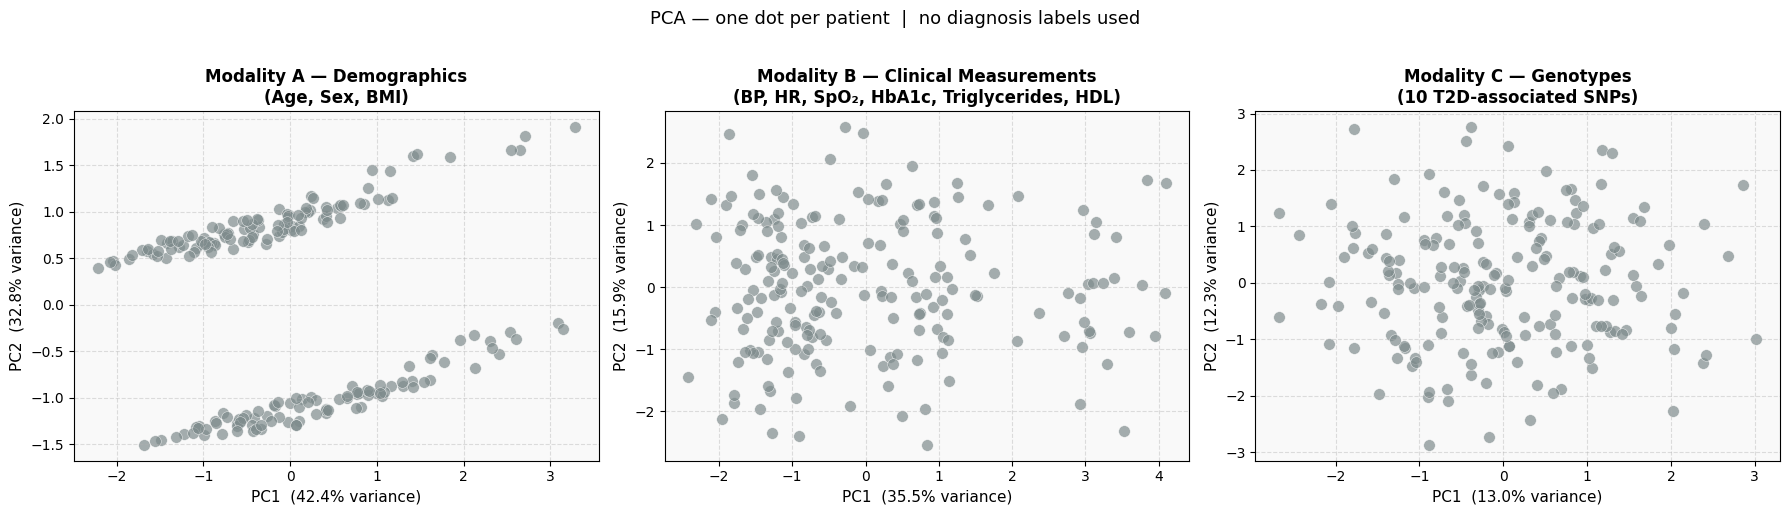

In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Colour palette and label order (defined here, reused throughout) ──────────
label_colors = {
    "Healthy"      : "#2ecc71",   # green
    "Pre-diabetes" : "#f39c12",   # orange
    "Diabetes"     : "#e74c3c",   # red
}
label_order = ["Healthy", "Pre-diabetes", "Diabetes"]

# ── Helper: fit PCA and return coordinates + fitted objects for later use ──────
def run_pca(feature_matrix):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(feature_matrix)
    pca    = PCA(n_components=2, random_state=RANDOM_SEED)
    coords = pca.fit_transform(scaled)
    var_explained = pca.explained_variance_ratio_ * 100
    return coords, var_explained, scaler, pca

# ── Prepare feature matrices ───────────────────────────────────────────────────
sex_encoded = LabelEncoder().fit_transform(modality_A["Sex"])

features_A = np.column_stack([
    modality_A["Age"].values,
    sex_encoded,
    modality_A["BMI"].values,
])

features_B = modality_B[[
    "Systolic BP (mmHg)",
    "Diastolic BP (mmHg)",
    "Heart Rate (bpm)",
    "SpO2 (%)",
    "HbA1c (mmol/mol)",
    "Triglycerides (mmol/L)",
    "HDL Cholesterol (mmol/L)",
]].values

features_C = modality_C.drop(columns=["Name", "Label"]).values

# ── Run PCA ────────────────────────────────────────────────────────────────────
pca_A, var_A, scaler_A, pca_obj_A = run_pca(features_A)
pca_B, var_B, scaler_B, pca_obj_B = run_pca(features_B)
pca_C, var_C, scaler_C, pca_obj_C = run_pca(features_C)

# ── Plot — unlabeled (all patients the same colour) ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panels = [
    (axes[0], pca_A, var_A, "Modality A — Demographics\n(Age, Sex, BMI)"),
    (axes[1], pca_B, var_B, "Modality B — Clinical Measurements\n(BP, HR, SpO₂, HbA1c, Triglycerides, HDL)"),
    (axes[2], pca_C, var_C, "Modality C — Genotypes\n(10 T2D-associated SNPs)"),
]

for ax, coords, var, title in panels:
    ax.scatter(
        coords[:, 0], coords[:, 1],
        c="#7f8c8d", alpha=0.70, edgecolors="white", linewidths=0.4, s=70,
    )
    ax.set_xlabel(f"PC1  ({var[0]:.1f}% variance)", fontsize=11)
    ax.set_ylabel(f"PC2  ({var[1]:.1f}% variance)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_facecolor("#f9f9f9")

fig.suptitle(
    "PCA — one dot per patient  |  no diagnosis labels used",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

**Questions:**
- Can you see patterns in the data?
- What could explain these patterns?

We now add labels (diagnoses) to the data. Do to unsupervised learning.

Each patient is colored according to diagnosis so we can see whether the model’s patterns align with clinical reality. 



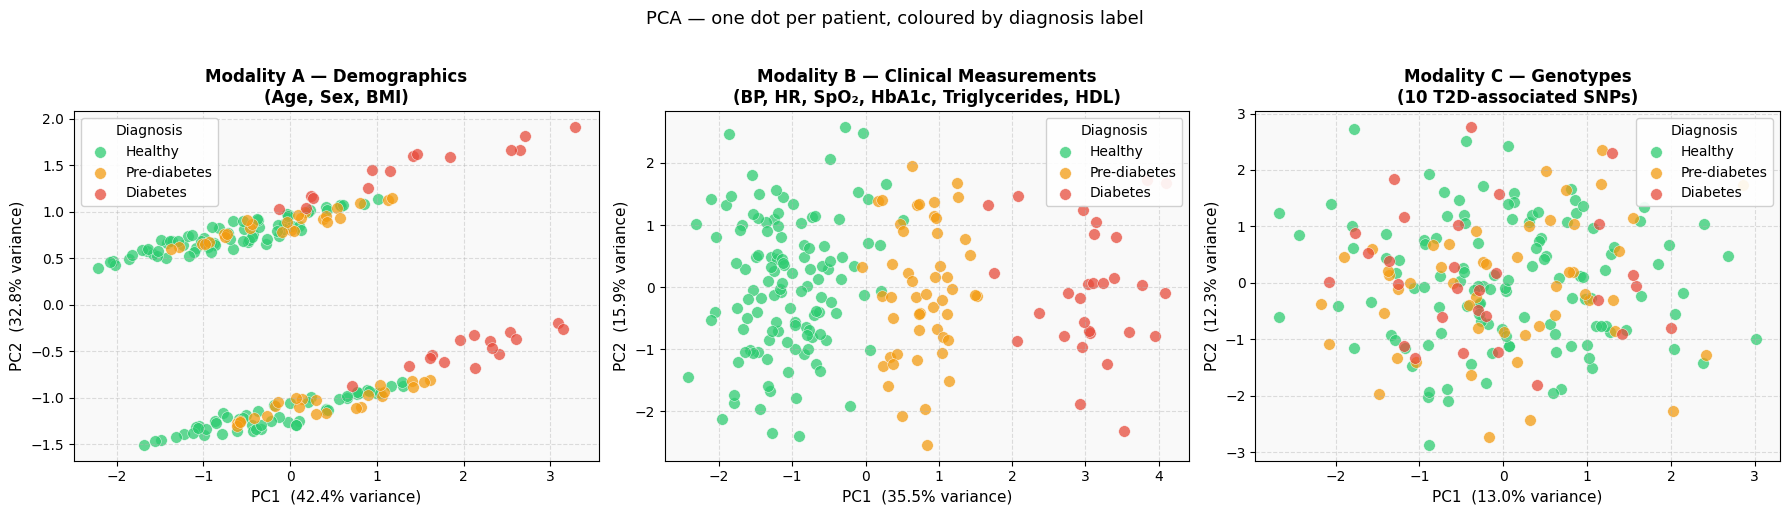

In [6]:
# ── Plot — labelled by diagnosis ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panels = [
    (axes[0], pca_A, var_A, "Modality A — Demographics\n(Age, Sex, BMI)"),
    (axes[1], pca_B, var_B, "Modality B — Clinical Measurements\n(BP, HR, SpO₂, HbA1c, Triglycerides, HDL)"),
    (axes[2], pca_C, var_C, "Modality C — Genotypes\n(10 T2D-associated SNPs)"),
]

for ax, coords, var, title in panels:
    for lbl in label_order:
        mask = modality_A["Label"] == lbl
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=label_colors[lbl], label=lbl,
            alpha=0.75, edgecolors="white", linewidths=0.4, s=70,
        )
    ax.set_xlabel(f"PC1  ({var[0]:.1f}% variance)", fontsize=11)
    ax.set_ylabel(f"PC2  ({var[1]:.1f}% variance)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(title="Diagnosis", framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_facecolor("#f9f9f9")

fig.suptitle(
    "PCA — one dot per patient, coloured by diagnosis label",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

**Questions:**
- Can you see patterns in the data?
- What could explain these patterns?

## What Drives the Model?
The heatmap helps us understand what drives the model.

The more red a color is, the greater the contribution of that variable — blue means little or no contribution.


In [7]:
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

def plot_pca_analysis(features, feature_names, pca_coords, pca_obj, scaler,
                      var, diagnosis_labels, title):
    """
    Two plots for one modality (PC1 only):
      1. Loadings bar chart  — which features drive PC1
      2. Contribution heatmap — per-feature PC1 contributions for every individual
    """
    n_features = len(feature_names)
    n_patients = features.shape[0]
    loadings   = pca_obj.components_          # (2, n_features)

    # ── Plot 2: PC1 Contribution heatmap ──────────────────────────────────────
    X_scaled      = scaler.transform(features)
    sort_idx      = np.argsort(pca_coords[:, 0])
    X_sorted      = X_scaled[sort_idx]
    labels_sorted = np.asarray(diagnosis_labels)[sort_idx]

    pc1_contrib = loadings[0, :, np.newaxis] * X_sorted.T   # (n_features, N)
    heat        = pc1_contrib

    lbl_int = {"Healthy": 0, "Pre-diabetes": 1, "Diabetes": 2}
    strip   = np.array([lbl_int[l] for l in labels_sorted])[np.newaxis, :]

    fig = plt.figure(figsize=(16, 2.5 + n_features * 0.6))
    gs  = gridspec.GridSpec(
        2, 2,
        height_ratios=[0.12, 1], width_ratios=[1, 0.03],
        hspace=0.04, wspace=0.02,
    )
    ax_strip  = fig.add_subplot(gs[0, 0])
    ax_heat   = fig.add_subplot(gs[1, 0])
    ax_cbar   = fig.add_subplot(gs[1, 1])
    ax_spacer = fig.add_subplot(gs[0, 1])
    ax_spacer.set_visible(False)

    diag_cmap = ListedColormap(["#2ecc71", "#f39c12", "#e74c3c"])
    ax_strip.pcolormesh(strip, cmap=diag_cmap, vmin=-0.5, vmax=2.5)
    ax_strip.set_xlim(0, n_patients)
    ax_strip.set_ylim(0, 1)
    ax_strip.set_yticks([0.5])
    ax_strip.set_yticklabels(["Diagnosis"], fontsize=9)
    ax_strip.set_xticks([])
    ax_strip.set_title(
        f"{title} — per-feature contributions to PC1 score",
        fontsize=11, fontweight="bold", pad=6, loc="left",
    )
    ax_strip.legend(
        handles=[
            mpatches.Patch(color="#2ecc71", label="Healthy"),
            mpatches.Patch(color="#f39c12", label="Pre-diabetes"),
            mpatches.Patch(color="#e74c3c", label="Diabetes"),
        ],
        loc="upper right",
        bbox_to_anchor=(1.0, 1.45),
        bbox_transform=ax_strip.transAxes,
        fontsize=8, framealpha=0.9, ncol=3, borderaxespad=0,
    )

    vmax = np.abs(heat).max()
    im   = ax_heat.pcolormesh(heat, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax_heat.set_xlim(0, n_patients)
    ax_heat.set_ylim(n_features, 0)

    row_labels = [f"PC1  ←  {n}" for n in feature_names]
    ax_heat.set_yticks([r + 0.5 for r in range(n_features)])
    ax_heat.set_yticklabels(row_labels, fontsize=9)

    ax_heat.text(
        n_patients + 2, n_features / 2, "PC1",
        fontsize=10, fontweight="bold",
        va="center", ha="left", color="#2980b9", clip_on=False,
    )

    ax_heat.set_xlabel(
        "Individuals  (leftmost: lowest PC1 score  ·  rightmost: highest PC1 score)",
        fontsize=10,
    )

    cb = plt.colorbar(im, cax=ax_cbar)
    cb.set_label("Contribution to PC1 score (loading × standardised value)", fontsize=9)

    plt.tight_layout()
    plt.show()

- Modality A — Demographics (Age, Sex, BMI) 

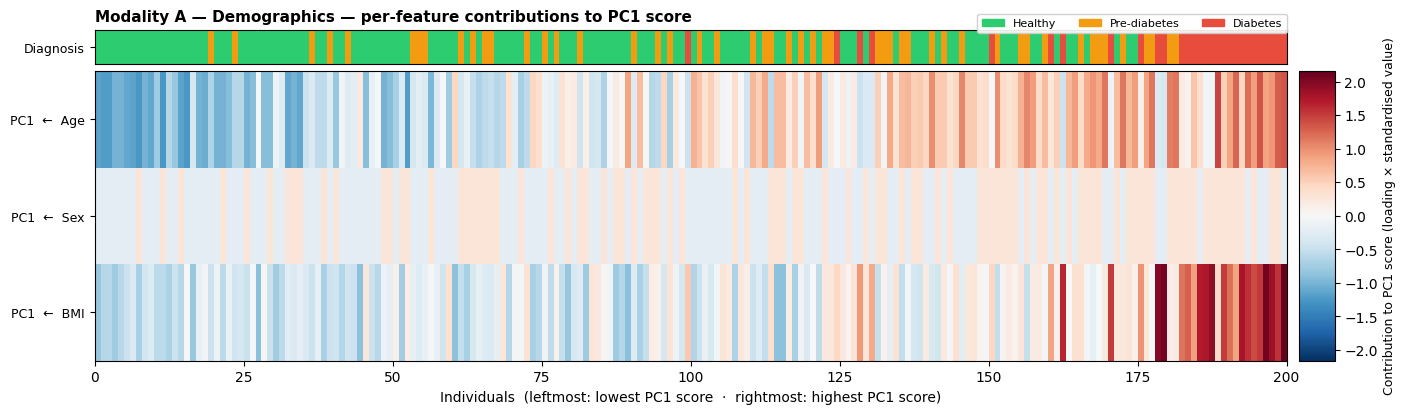

In [8]:
plot_pca_analysis(
    features       = features_A,
    feature_names  = ["Age", "Sex", "BMI"],
    pca_coords     = pca_A,
    pca_obj        = pca_obj_A,
    scaler         = scaler_A,
    var            = var_A,
    diagnosis_labels = modality_A["Label"].values,
    title          = "Modality A — Demographics",
)

- Modality B — Clinical Measurements (BP, HR, SpO₂, HbA1c, Triglycerides, HDL)

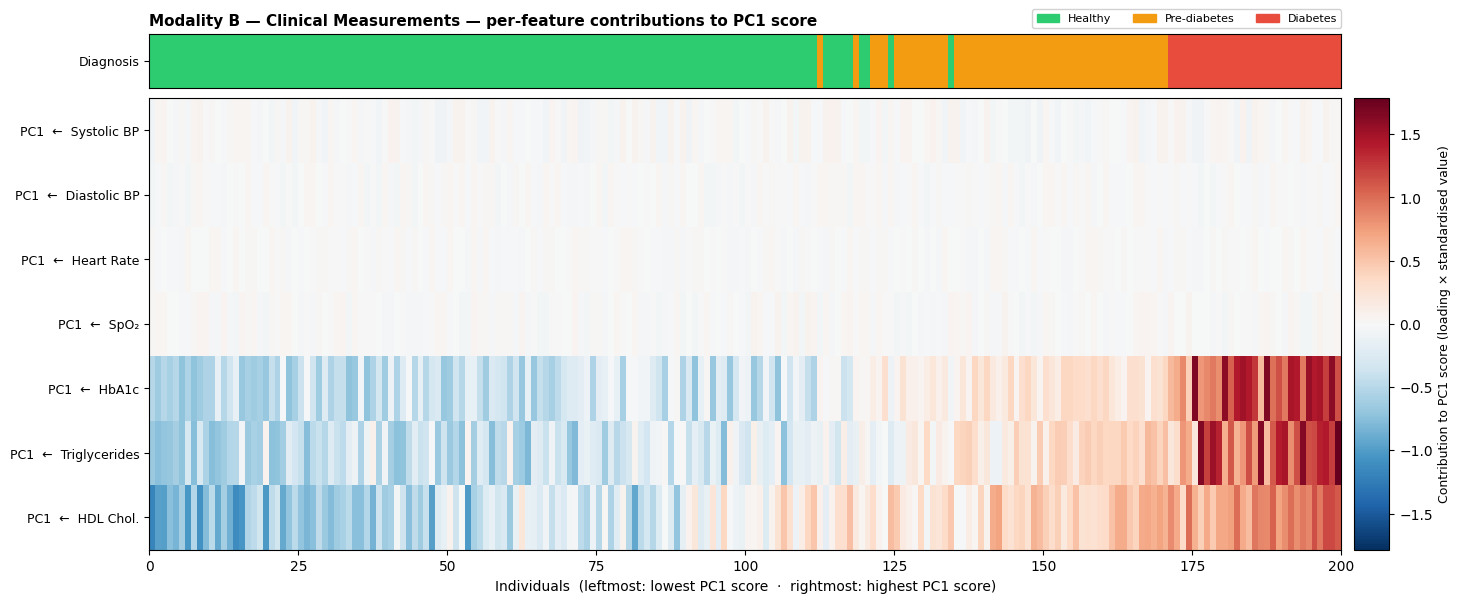

In [9]:
plot_pca_analysis(
    features       = features_B,
    feature_names  = ["Systolic BP", "Diastolic BP", "Heart Rate", "SpO₂", "HbA1c",
                      "Triglycerides", "HDL Chol."],
    pca_coords     = pca_B,
    pca_obj        = pca_obj_B,
    scaler         = scaler_B,
    var            = var_B,
    diagnosis_labels = modality_B["Label"].values,
    title          = "Modality B — Clinical Measurements",
)

- Modality C — SNP Genotypes (10 T2D-associated variants)

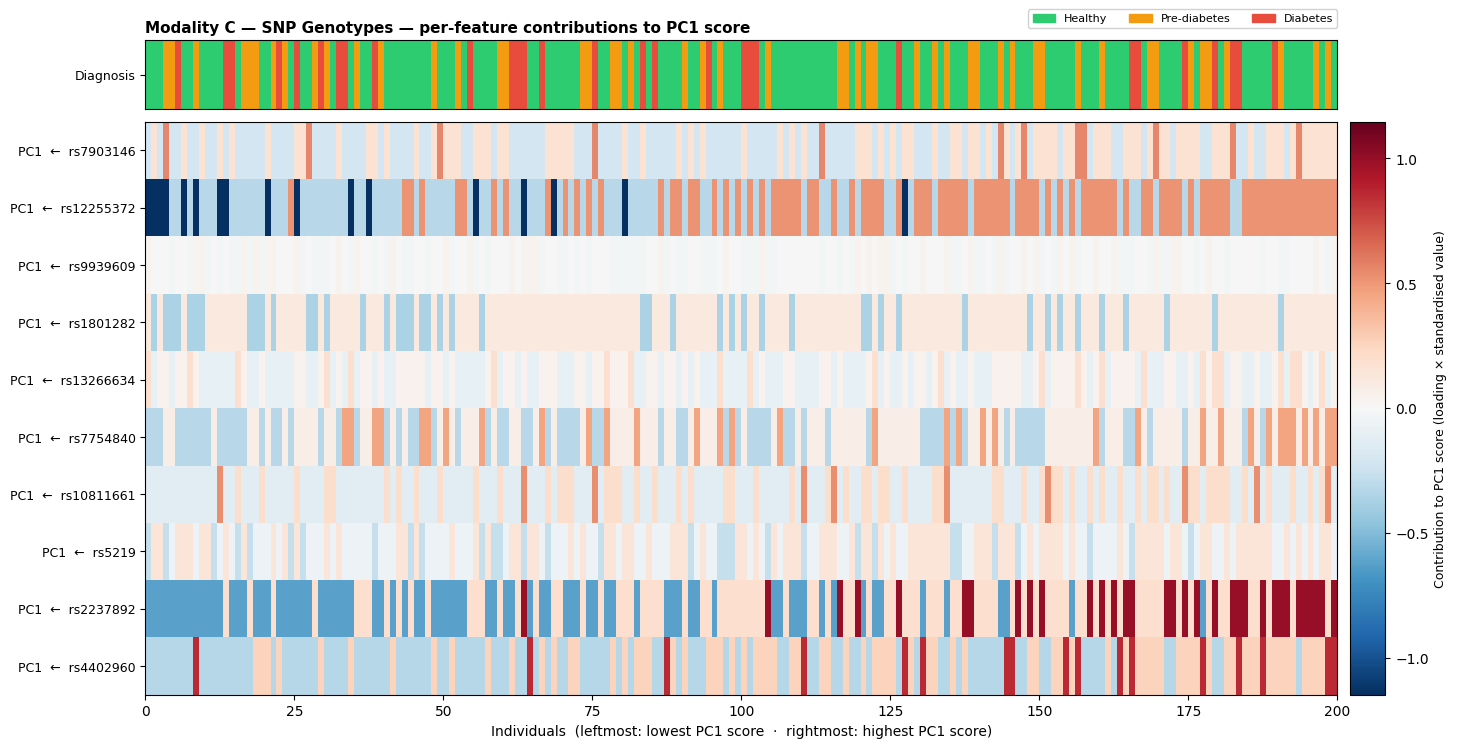

In [10]:
plot_pca_analysis(
    features       = features_C,
    feature_names  = [
        "rs7903146", "rs12255372", "rs9939609", "rs1801282", "rs13266634",
        "rs7754840", "rs10811661", "rs5219", "rs2237892", "rs4402960",
    ],
    pca_coords     = pca_C,
    pca_obj        = pca_obj_C,
    scaler         = scaler_C,
    var            = var_C,
    diagnosis_labels = modality_C["Label"].values,
    title          = "Modality C — SNP Genotypes",
)

**Questions:**
- Which modality appears to contribute most to the model’s output?
- Which variables appear most important?

**Summary**

We have now seen:
- how the data look
- how patients cluster
- what drives the model’s predictions

The model is an AI-based multimodal model that combines several types of data — but not all modalities contribute equally.



## You are now ready to run a real patient through the model.

We begin with Maria and examine where she is placed and what drives the model’s assessment.

**Maria in the Model** 

Maria is shown as a star in the PCA plot.


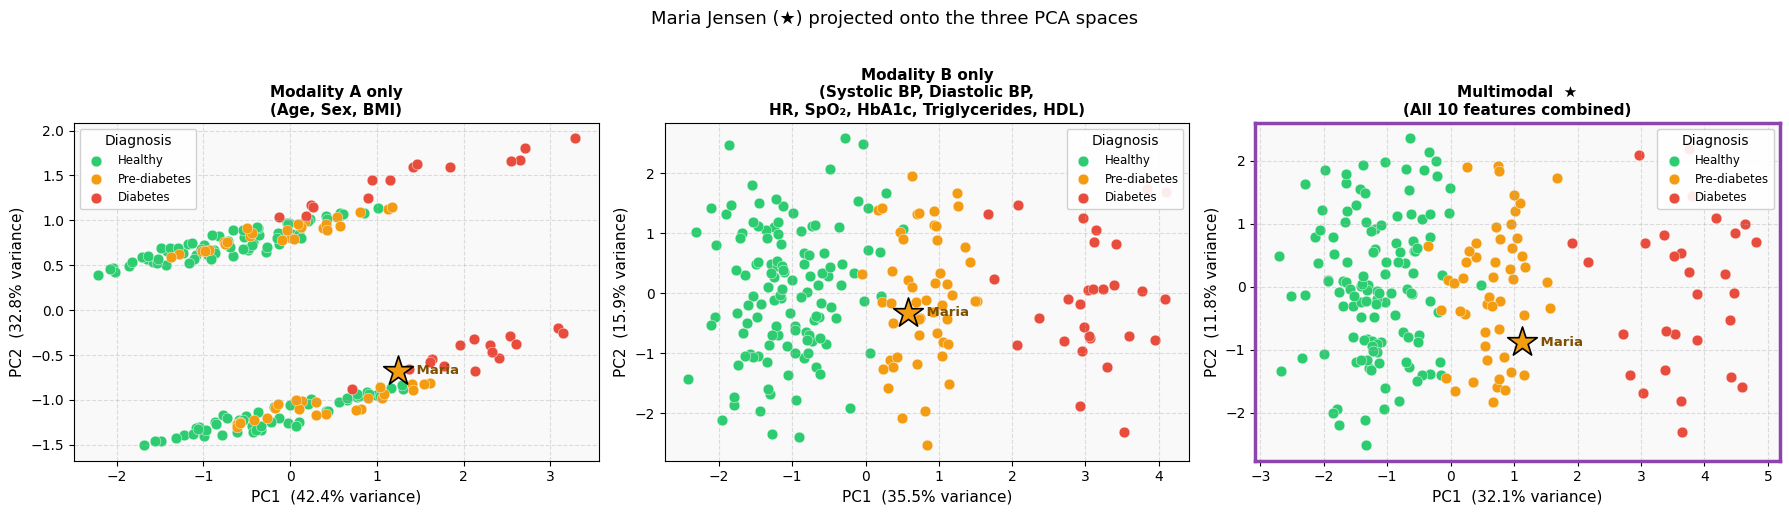

In [11]:
def plot_patient_contributions(patient_raw, features, feature_names, pca_obj, scaler,
                               diagnosis_labels, pca_coords, title, patient_name="Patient"):
    """
    Patient-only PC1 contribution panel.

    Shows the patient's per-feature PC1 contributions as a single colour column
    with the numeric value printed inside each cell.
    """
    n_features = len(feature_names)
    loadings   = pca_obj.components_          # (2, n_features)

    # ── Patient ────────────────────────────────────────────────────────────────
    patient_scaled = scaler.transform(patient_raw)        # (1, n_features)
    pc1_pat  = loadings[0, :] * patient_scaled[0, :]     # (n_features,)
    heat_pat = pc1_pat[:, np.newaxis]                     # (n_features, 1)

    vmax = np.abs(heat_pat).max()

    # ── Figure ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(5, 2.0 + n_features * 0.5))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 0.08], wspace=0.06)
    ax_heat_pat = fig.add_subplot(gs[0, 0])
    ax_cbar     = fig.add_subplot(gs[0, 1])

    im = ax_heat_pat.pcolormesh(heat_pat, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax_heat_pat.set_xlim(0, 1)
    ax_heat_pat.set_ylim(n_features, 0)
    ax_heat_pat.set_xticks([])
    ax_heat_pat.set_yticks([r + 0.5 for r in range(n_features)])
    ax_heat_pat.set_yticklabels([f"PC1  ←  {n}" for n in feature_names], fontsize=9)
    ax_heat_pat.set_title(
        f"{title} — PC1 feature contributions {patient_name}",
        fontsize=11, fontweight="bold", color="darkred", pad=6,
    )
    for spine in ax_heat_pat.spines.values():
        spine.set_edgecolor("#f1c40f")
        spine.set_linewidth(2)

    for r, val in enumerate(pc1_pat):
        txt_color = "white" if abs(val) > 0.4 * vmax else "black"
        ax_heat_pat.text(0.5, r + 0.5, f"{val:+.2f}",
                         ha="center", va="center",
                         fontsize=9, fontweight="bold", color=txt_color)

    cb = plt.colorbar(im, cax=ax_cbar)
    cb.set_label("Contribution (loading × std. value)", fontsize=9)

    plt.tight_layout()
    plt.show()

# ── Build all combined feature matrices ───────────────────────────────────────
# features_A, features_B, features_C were prepared in Step 2
features_AB  = np.hstack([features_A, features_B])
features_AC  = np.hstack([features_A, features_C])
features_BC  = np.hstack([features_B, features_C])
features_ABC = np.hstack([features_A, features_B, features_C])

# ── Run PCA on each combined matrix ───────────────────────────────────────────
pca_AB,  var_AB,  scaler_AB,  pca_obj_AB  = run_pca(features_AB)
pca_AC,  var_AC,  scaler_AC,  pca_obj_AC  = run_pca(features_AC)
pca_BC,  var_BC,  scaler_BC,  pca_obj_BC  = run_pca(features_BC)
pca_ABC, var_ABC, scaler_ABC, pca_obj_ABC = run_pca(features_ABC)

# Keep the old "combined" references pointing to A+B for backwards compatibility
pca_combined    = pca_AB
var_combined    = var_AB
scaler_combined = scaler_AB
pca_obj_combined = pca_obj_AB

# ── Maria's measurements ───────────────────────────────────────────────────────
# Sex encoded the same way as the training data: Female = 0, Male = 1
maria_A_raw = np.array([[45, 0, 31.2]])                          # Age, Sex (Female=0), BMI
maria_B_raw = np.array([[130, 86, 76, 97.8, 39, 2.1, 1.2]])     # SysBP, DiaBP, HR, SpO2, HbA1c, Triglycerides, HDL

maria_combined_raw = np.hstack([maria_A_raw, maria_B_raw])

# ── Project onto each PCA space (transform only — no refitting) ───────────────
maria_pca_A        = pca_obj_A.transform(scaler_A.transform(maria_A_raw))
maria_pca_B        = pca_obj_B.transform(scaler_B.transform(maria_B_raw))
maria_pca_combined = pca_obj_combined.transform(scaler_combined.transform(maria_combined_raw))

# ── Three-panel plot with Maria highlighted ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panels = [
    (axes[0], pca_A,        var_A,        maria_pca_A,        "Modality A only\n(Age, Sex, BMI)"),
    (axes[1], pca_B,        var_B,        maria_pca_B,        "Modality B only\n(Systolic BP, Diastolic BP,\nHR, SpO₂, HbA1c, Triglycerides, HDL)"),
    (axes[2], pca_combined, var_combined, maria_pca_combined, "Multimodal  ★\n(All 10 features combined)"),
]

for ax, coords, var, maria_coords, title in panels:
    # Background population
    for lbl in label_order:
        mask = modality_A["Label"] == lbl
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=label_colors[lbl], label=lbl,
            alpha=1, edgecolors="white", linewidths=0.3, s=60,
        )
    # Maria — large star marker; label="_nolegend_" keeps her out of the legend box
    ax.scatter(
        maria_coords[0, 0], maria_coords[0, 1],
        marker="*", s=500,
        c=label_colors["Pre-diabetes"],
        edgecolors="black", linewidths=1.2,
        zorder=5, label="_nolegend_",
    )
    ax.annotate(
        "    Maria",
        xy=(maria_coords[0, 0], maria_coords[0, 1]),
        fontsize=9.5, fontweight="bold", color="#7f4f00",
        va="center",
    )
    ax.set_xlabel(f"PC1  ({var[0]:.1f}% variance)", fontsize=11)
    ax.set_ylabel(f"PC2  ({var[1]:.1f}% variance)", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(title="Diagnosis", framealpha=0.9, fontsize=8.5)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_facecolor("#f9f9f9")

# Highlight the multimodal panel
for spine in axes[2].spines.values():
    spine.set_edgecolor("#8e44ad")
    spine.set_linewidth(2.5)

fig.suptitle(
    "Maria Jensen (★) projected onto the three PCA spaces",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

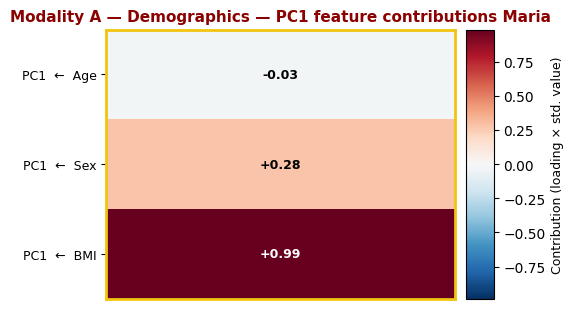

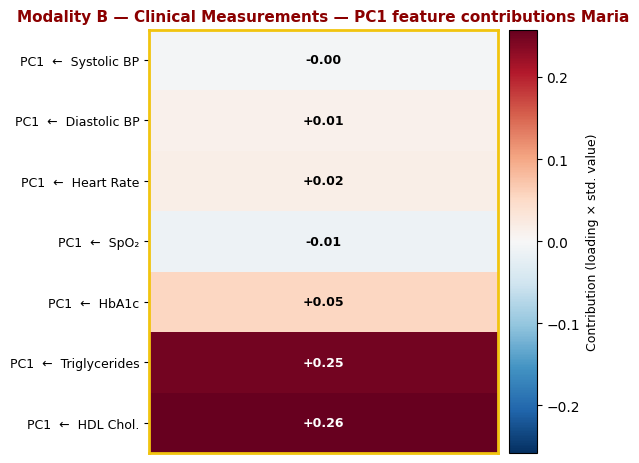

In [12]:
plot_patient_contributions(
    patient_raw      = maria_A_raw,
    features         = features_A,
    feature_names    = ["Age", "Sex", "BMI"],
    pca_obj          = pca_obj_A,
    scaler           = scaler_A,
    diagnosis_labels = modality_A["Label"].values,
    pca_coords       = pca_A,
    title            = "Modality A — Demographics",
    patient_name     = "Maria",
)

plot_patient_contributions(
    patient_raw      = maria_B_raw,
    features         = features_B,
    feature_names    = ["Systolic BP", "Diastolic BP", "Heart Rate", "SpO₂", "HbA1c",
                        "Triglycerides", "HDL Chol."],
    pca_obj          = pca_obj_B,
    scaler           = scaler_B,
    diagnosis_labels = modality_B["Label"].values,
    pca_coords       = pca_B,
    title            = "Modality B — Clinical Measurements",
    patient_name     = "Maria",
)

**Questions:**
- Which modalities and variables appear to drive the model’s assessment of Maria?
- Does combining multiple modalities provide a more complete assessment of Maria?

**Peter in the model:**

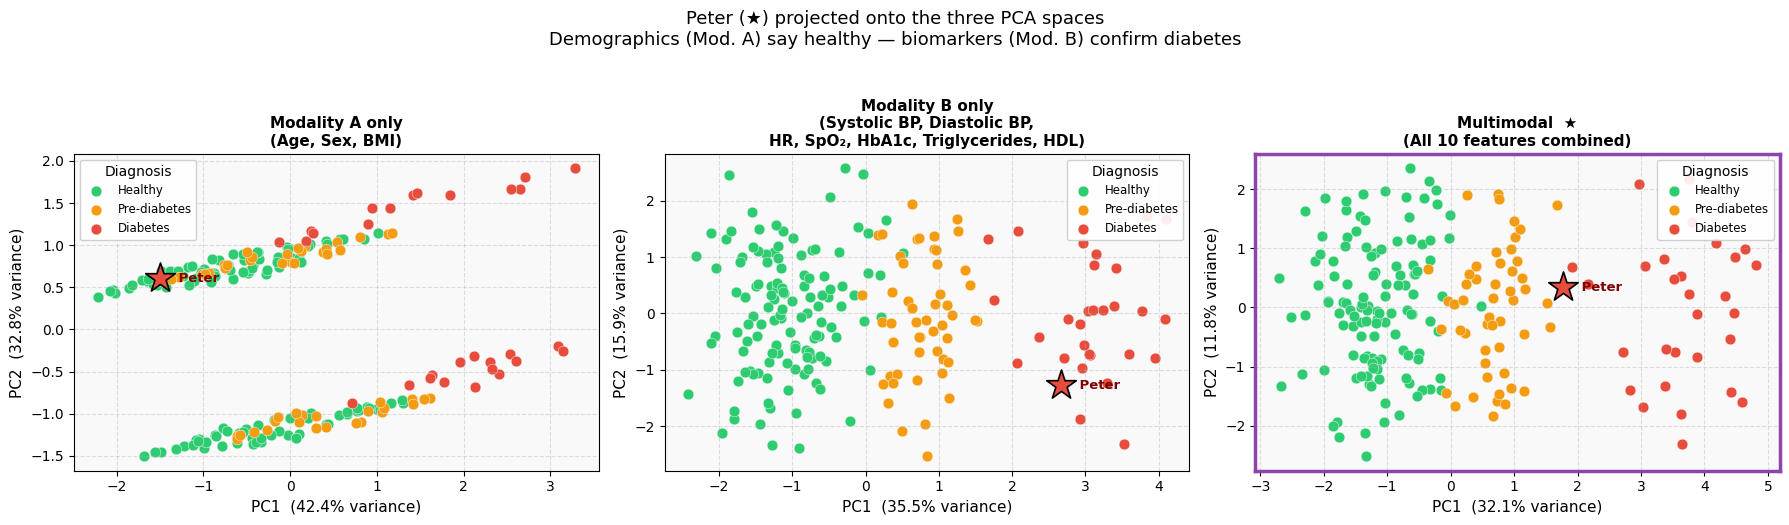

In [13]:
# ── Peter's measurements ───────────────────────────────────────────────────────
# Modality A: Age=27, Sex=Male (1), BMI=22.3 — young and lean, looks healthy demographically
peter_A_raw = np.array([[27, 1, 22.3]])
# Modality B: HbA1c=61 mmol/mol (diabetes threshold: 48), elevated triglycerides, low HDL
peter_B_raw = np.array([[128, 82, 74, 98.1, 61, 3.0, 0.82]])
peter_combined_raw = np.hstack([peter_A_raw, peter_B_raw])

# ── Project onto the same PCA spaces (no refitting) ──────────────────────────
peter_pca_A        = pca_obj_A.transform(scaler_A.transform(peter_A_raw))
peter_pca_B        = pca_obj_B.transform(scaler_B.transform(peter_B_raw))
peter_pca_combined = pca_obj_combined.transform(scaler_combined.transform(peter_combined_raw))

# ── Three-panel plot with Peter highlighted ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panels = [
    (axes[0], pca_A,        var_A,        peter_pca_A,        "Modality A only\n(Age, Sex, BMI)"),
    (axes[1], pca_B,        var_B,        peter_pca_B,        "Modality B only\n(Systolic BP, Diastolic BP,\nHR, SpO\u2082, HbA1c, Triglycerides, HDL)"),
    (axes[2], pca_combined, var_combined, peter_pca_combined, "Multimodal  \u2605\n(All 10 features combined)"),
]

for ax, coords, var, p_coords, title in panels:
    for lbl in label_order:
        mask = modality_A["Label"] == lbl
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=label_colors[lbl], label=lbl,
            alpha=1, edgecolors="white", linewidths=0.3, s=60,
        )
    ax.scatter(
        p_coords[0, 0], p_coords[0, 1],
        marker="*", s=500, c=label_colors["Diabetes"],
        edgecolors="black", linewidths=1.2,
        zorder=5, label="_nolegend_",
    )
    ax.annotate(
        "    Peter", xy=(p_coords[0, 0], p_coords[0, 1]),
        fontsize=9.5, fontweight="bold", color="#7f0000", va="center",
    )
    ax.set_xlabel(f"PC1  ({var[0]:.1f}% variance)", fontsize=11)
    ax.set_ylabel(f"PC2  ({var[1]:.1f}% variance)", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(title="Diagnosis", framealpha=0.9, fontsize=8.5)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_facecolor("#f9f9f9")

for spine in axes[2].spines.values():
    spine.set_edgecolor("#8e44ad")
    spine.set_linewidth(2.5)

fig.suptitle(
    "Peter (\u2605) projected onto the three PCA spaces\n"
    "Demographics (Mod. A) say healthy — biomarkers (Mod. B) confirm diabetes",
    fontsize=13, y=1.04,
)
plt.tight_layout()
plt.show()

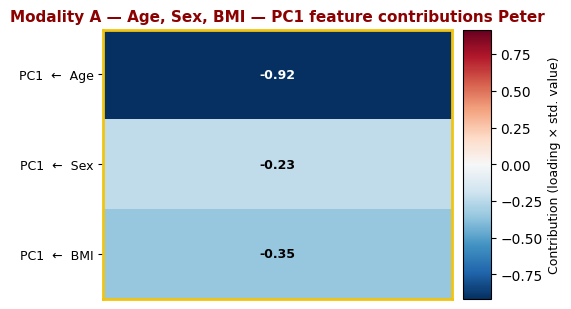

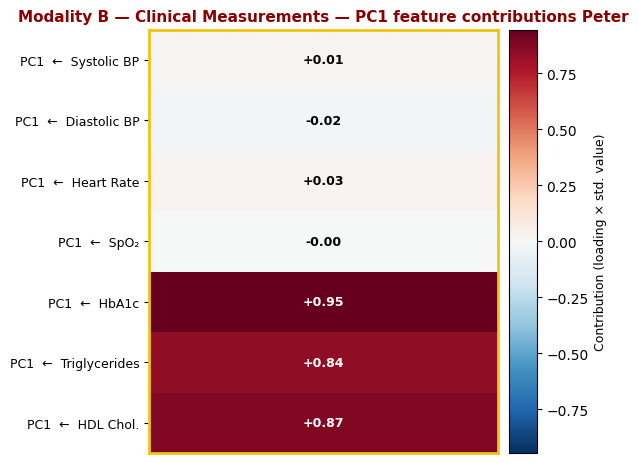

In [14]:
plot_patient_contributions(
    patient_raw      = peter_A_raw,
    features         = features_A,
    feature_names    = ["Age", "Sex", "BMI"],
    pca_obj          = pca_obj_A,
    scaler           = scaler_A,
    diagnosis_labels = modality_A["Label"].values,
    pca_coords       = pca_A,
    title            = "Modality A — Age, Sex, BMI",
    patient_name     = "Peter",
)

plot_patient_contributions(
    patient_raw      = peter_B_raw,
    features         = features_B,
    feature_names    = ["Systolic BP", "Diastolic BP", "Heart Rate", "SpO\u2082", "HbA1c",
                        "Triglycerides", "HDL Chol."],
    pca_obj          = pca_obj_B,
    scaler           = scaler_B,
    diagnosis_labels = modality_B["Label"].values,
    pca_coords       = pca_B,
    title            = "Modality B — Clinical Measurements",
    patient_name     = "Peter",
)

**Questions:**
- Which modalities and variables drive the model’s assessment of Peter?
- Does combining multiple modalities provide a more complete assessment of Peter?

**Summary**

- Maria:

The modalities point in the same direction and support the same interpretation.
- Peter:

The modalities do not point completely in the same direction. The clinical measurements clearly indicate diabetes, while the demographic profile fits less well with the typical pattern.
- This shows that multimodal models can be powerful — but can also struggle with patients who do not fit the patterns most commonly seen during training.


## Digital Twins — Genetics and Treatment Selection
We now investigate how the model can be used to suggest possible treatments for Maria and Peter.

Until now, the model has been used to identify disease-related patterns.

Now the focus shifts from diagnosis to treatment.

Genetics (Modality C) becomes more relevant here because genetic variation can influence how patients respond to different medications.

**The goal is to investigate:**
- whether patients with the same diagnosis necessarily require the same treatment
- whether genetic data can contribute to a more personalized assessment
- how multimodal models can support treatment selection

Maria — Possible Treatment in the Genetic Model

Although Maria does not yet have type 2 diabetes, genetic data may still be relevant for risk assessment and possible treatment.

Here, Maria is compared with other patients with prediabetes, some of whom have responded well to treatments such as Ozempic.


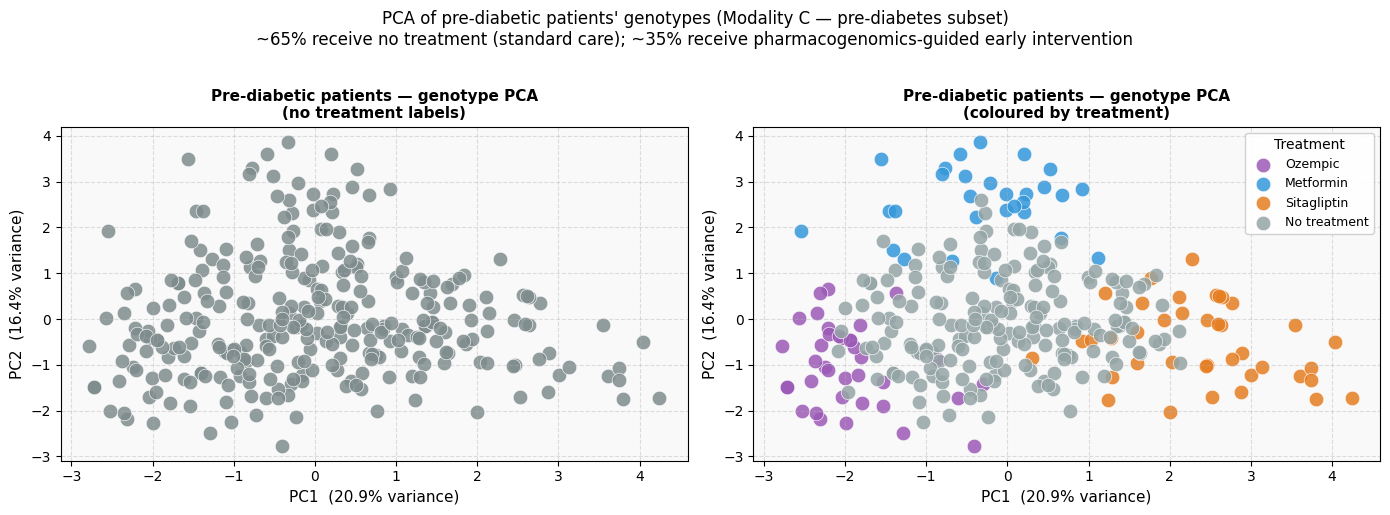

In [15]:
# ── Step 7.1 — Drug assignment for pre-diabetic patients ──────────────────────

snp_cols = [c for c in modality_C.columns if c not in ("Name", "Label")]

# Pharmacogenomics weight matrix
drug_snp_weights = {
    "Ozempic": {           # GLP-1 receptor agonist (semaglutide)
        "rs7903146":  2.0,   # TCF7L2 — strongest predictor of GLP-1 RA response
        "rs12255372": 1.5,   # TCF7L2
        "rs9939609":  0.5,   # FTO (moderate)
        "rs1801282": -0.3,   # PPARG (prefers metformin)
        "rs13266634": 0.2,
        "rs7754840":  0.8,   # CDKAL1
        "rs10811661": 0.3,
        "rs5219":    -0.8,   # KCNJ11 (prefers sitagliptin)
        "rs2237892": -0.5,   # KCNQ1 (prefers sitagliptin)
        "rs4402960":  0.2,
    },
    "Metformin": {
        "rs7903146": -0.5,
        "rs12255372":-0.3,
        "rs9939609":  1.0,   # FTO — obesity / insulin resistance
        "rs1801282":  2.0,   # PPARG — insulin sensitivity
        "rs13266634": 1.5,   # SLC30A8 — zinc transporter
        "rs7754840":  0.5,
        "rs10811661": 0.3,
        "rs5219":     0.5,
        "rs2237892": -0.2,
        "rs4402960":  0.3,
    },
    "Sitagliptin": {       # DPP-4 inhibitor
        "rs7903146": -0.3,
        "rs12255372":-0.2,
        "rs9939609": -0.5,
        "rs1801282": -0.5,
        "rs13266634": 0.3,
        "rs7754840":  0.2,
        "rs10811661": 0.8,   # CDKN2A/B — beta-cell proliferation
        "rs5219":     2.0,   # KCNJ11 — beta-cell K+ channel
        "rs2237892":  1.5,   # KCNQ1
        "rs4402960":  1.5,   # IGF2BP2
    },
}

# ── Generate a larger structured pre-diabetic cohort for the drug section ─────
# Each patient is drawn from one of three pharmacogenomics archetypes so that
# drug-relevant SNPs cluster together in PCA space.
# SNP structure is INDEPENDENT of diagnosis — consistent with Modality C design.

rng_drug = np.random.default_rng(RANDOM_SEED + 300)
n_drug_patients = 300

# Archetype assignment: ~25% Ozempic, ~15% Metformin, ~15% Sitagliptin, ~45% None
archetypes = rng_drug.choice(
    ["Ozempic", "Metformin", "Sitagliptin", "None"],
    size=n_drug_patients,
    p=[0.25, 0.15, 0.15, 0.45],
)

# Per-archetype MAFs: elevated for pharmacogenomically relevant SNPs
# snp order: rs7903146, rs12255372, rs9939609, rs1801282, rs13266634,
#            rs7754840, rs10811661, rs5219,    rs2237892, rs4402960
base_mafs = [0.30, 0.28, 0.43, 0.12, 0.32, 0.38, 0.18, 0.35, 0.40, 0.30]
archetype_mafs = {
    "Ozempic":     [0.68, 0.63, 0.40, 0.10, 0.25, 0.52, 0.15, 0.15, 0.18, 0.22],
    "Metformin":   [0.18, 0.16, 0.72, 0.58, 0.68, 0.35, 0.20, 0.22, 0.18, 0.25],
    "Sitagliptin": [0.18, 0.16, 0.25, 0.10, 0.25, 0.22, 0.58, 0.72, 0.68, 0.62],
    "None":        base_mafs,
}

snp_data_drug = {snp: [] for snp in snp_cols}
for arch in archetypes:
    for snp, maf in zip(snp_cols, archetype_mafs[arch]):
        p0, p1, p2 = (1 - maf)**2, 2*maf*(1-maf), maf**2
        snp_data_drug[snp].append(int(rng_drug.choice([0, 1, 2], p=[p0, p1, p2])))

prediab_geno  = pd.DataFrame(snp_data_drug)
prediab_names = [f"S{i:04d}" for i in range(n_drug_patients)]

# Compute all 3 drug scores and assign treatment
score_rows = []
for _, row in prediab_geno.iterrows():
    scores = {}
    for drug, weights in drug_snp_weights.items():
        raw = sum(row[snp] * weights[snp] for snp in snp_cols)
        scores[drug] = raw + rng_drug.normal(0, 0.2)
    score_rows.append(scores)

drug_scores_df = pd.DataFrame(score_rows)
best_drug  = drug_scores_df.idxmax(axis=1)
best_score = drug_scores_df.max(axis=1)

# Top ~35% get pharmacogenomics-guided early treatment; rest get No treatment
pharma_threshold = np.percentile(best_score, 65)
assigned_drug = pd.Series(
    np.where(best_score >= pharma_threshold, best_drug.values, "No treatment")
)

# ── Step 7.2 — PCA of pre-diabetic patient genotypes, coloured by treatment ───

drug_colors = {
    "Ozempic":       "#9b59b6",   # purple
    "Metformin":     "#3498db",   # blue
    "Sitagliptin":   "#e67e22",   # amber
    "No treatment":  "#95a5a6",   # grey
}
drug_order = ["Ozempic", "Metformin", "Sitagliptin", "No treatment"]

# PCA on pre-diabetic patients' genotypes only
geno_prediab = prediab_geno[snp_cols].values
scaler_D     = StandardScaler()
geno_scaled  = scaler_D.fit_transform(geno_prediab)
pca_D_obj    = PCA(n_components=2, random_state=RANDOM_SEED)
pca_D        = pca_D_obj.fit_transform(geno_scaled)
var_D        = pca_D_obj.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: unlabelled (grey) — structure without treatment information
axes[0].scatter(pca_D[:, 0], pca_D[:, 1],
                c="#7f8c8d", alpha=0.85, edgecolors="white", linewidths=0.5, s=110)
axes[0].set_xlabel(f"PC1  ({var_D[0]:.1f}% variance)", fontsize=11)
axes[0].set_ylabel(f"PC2  ({var_D[1]:.1f}% variance)", fontsize=11)
axes[0].set_title("Pre-diabetic patients — genotype PCA\n(no treatment labels)", fontsize=11, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].set_facecolor("#f9f9f9")

# Right: coloured by treatment
for drug in drug_order:
    mask = assigned_drug.values == drug
    axes[1].scatter(
        pca_D[mask, 0], pca_D[mask, 1],
        c=drug_colors[drug], label=drug,
        alpha=0.85, edgecolors="white", linewidths=0.5, s=110,
    )
axes[1].set_xlabel(f"PC1  ({var_D[0]:.1f}% variance)", fontsize=11)
axes[1].set_ylabel(f"PC2  ({var_D[1]:.1f}% variance)", fontsize=11)
axes[1].set_title("Pre-diabetic patients — genotype PCA\n(coloured by treatment)", fontsize=11, fontweight="bold")
axes[1].legend(title="Treatment", framealpha=0.9, fontsize=9)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].set_facecolor("#f9f9f9")

fig.suptitle(
    "PCA of pre-diabetic patients' genotypes (Modality C — pre-diabetes subset)\n"
    "~65% receive no treatment (standard care); ~35% receive pharmacogenomics-guided early intervention",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

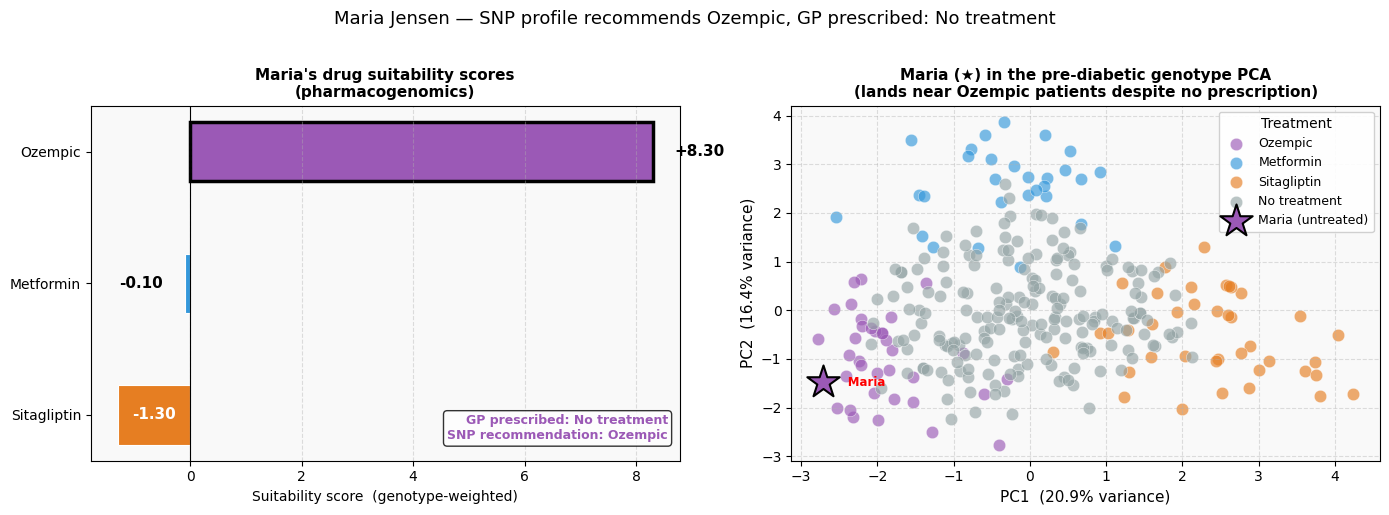

In [16]:
# ── Step 7.3 — Maria's genotype profile and drug recommendation ───────────────

# Maria's SNP dosages (same order as snp_cols)
# snp_cols: rs7903146, rs12255372, rs9939609, rs1801282, rs13266634,
#           rs7754840, rs10811661, rs5219, rs2237892, rs4402960
maria_geno_vals = [2, 2, 1, 0, 0,   # TCF7L2 x2, FTO, PPARG, SLC30A8
                   1, 0, 0, 0, 0]   # CDKAL1, CDKN2A/B, KCNJ11, KCNQ1, IGF2BP2
maria_geno = np.array([maria_geno_vals])

# Compute Maria's suitability scores (no noise — deterministic)
maria_scores = {}
for drug, weights in drug_snp_weights.items():
    maria_scores[drug] = sum(
        maria_geno_vals[i] * weights[snp] for i, snp in enumerate(snp_cols)
    )
maria_drug = max(maria_scores, key=maria_scores.get)

# Project Maria onto the pre-diabetic genotype PCA space
maria_geno_scaled = scaler_D.transform(maria_geno)
maria_pca_D       = pca_D_obj.transform(maria_geno_scaled)

# ── Two-panel figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Drug suitability bar chart (ascending -> highest at top)
drugs_sorted = sorted(maria_scores.items(), key=lambda x: x[1])
drug_names_s = [d for d, _ in drugs_sorted]
drug_vals_s  = [v for _, v in drugs_sorted]
bar_colors_s = [drug_colors[d] for d in drug_names_s]

bars = axes[0].barh(drug_names_s, drug_vals_s,
                    color=bar_colors_s, edgecolor="white", linewidth=0.8, height=0.45)

for bar, name in zip(bars, drug_names_s):
    if name == maria_drug:
        bar.set_edgecolor("black")
        bar.set_linewidth(2.5)
    val  = bar.get_width()
    span = max(drug_vals_s) - min(drug_vals_s)
    pad  = span * 0.04
    if name == "Sitagliptin":
        axes[0].text(val / 2, bar.get_y() + bar.get_height() / 2,
                     f"{val:+.2f}", va="center", ha="center",
                     fontsize=11, fontweight="bold", color="white")
    else:
        axes[0].text(val + pad if val >= 0 else val - pad,
                     bar.get_y() + bar.get_height() / 2,
                     f"{val:+.2f}", va="center",
                     ha="left" if val >= 0 else "right",
                     fontsize=11, fontweight="bold")

axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Suitability score  (genotype-weighted)", fontsize=10)
axes[0].set_title("Maria's drug suitability scores\n(pharmacogenomics)", fontsize=11, fontweight="bold")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)
axes[0].set_facecolor("#f9f9f9")
axes[0].text(0.98, 0.06,
             "GP prescribed: No treatment\nSNP recommendation: Ozempic",
             transform=axes[0].transAxes, ha="right", fontsize=9,
             color=drug_colors["Ozempic"], fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Right: PCA scatter with Maria overlaid
for drug in drug_order:
    mask = assigned_drug.values == drug
    axes[1].scatter(
        pca_D[mask, 0], pca_D[mask, 1],
        c=drug_colors[drug], label=drug,
        alpha=0.65, edgecolors="white", linewidths=0.4, s=80,
    )
axes[1].scatter(
    maria_pca_D[0, 0], maria_pca_D[0, 1],
    marker="*", s=600,
    c="#9b59b6",
    edgecolors="black", linewidths=1.5,
    zorder=5, label="Maria (untreated)",
)
axes[1].annotate(
    "      Maria",
    xy=(maria_pca_D[0, 0], maria_pca_D[0, 1]),
    fontsize=8.5, fontweight="bold", color="red",
    va="center",
)
axes[1].set_xlabel(f"PC1  ({var_D[0]:.1f}% variance)", fontsize=11)
axes[1].set_ylabel(f"PC2  ({var_D[1]:.1f}% variance)", fontsize=11)
axes[1].set_title("Maria (\u2605) in the pre-diabetic genotype PCA\n(lands near Ozempic patients despite no prescription)",
                  fontsize=11, fontweight="bold")
axes[1].legend(title="Treatment", framealpha=0.9, fontsize=9)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].set_facecolor("#f9f9f9")

fig.suptitle(
    f"Maria Jensen — SNP profile recommends {maria_drug}, GP prescribed: No treatment",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

**Question:**
- How might Maria’s genetic profile cause the model to place her closer to patients who responded well to Ozempic?

Peter — Possible Treatment in the Genetic Model

In type 2 diabetes, Metformin is often the first-line treatment.

Here, Peter is compared with other patients with similar genetic patterns and known treatment responses.


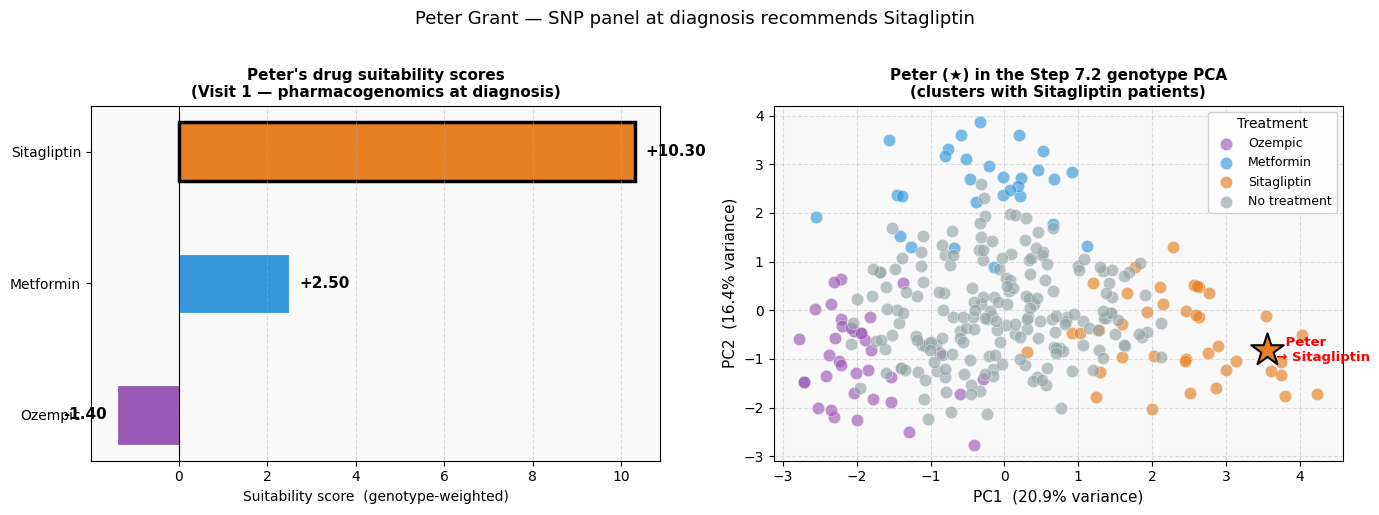

In [17]:
# ── Peter's genotype profile ──────────────────────────────────────────────────
# snp_cols order: rs7903146, rs12255372, rs9939609, rs1801282, rs13266634,
#                 rs7754840, rs10811661, rs5219,    rs2237892, rs4402960
peter_geno_vals = [0, 0, 1, 0, 0,   # TCF7L2 x0, FTO, PPARG, SLC30A8
                   0, 1, 2, 2, 2]   # CDKAL1, CDKN2A/B, KCNJ11, KCNQ1, IGF2BP2
peter_geno = np.array([peter_geno_vals])

# Drug suitability scores (deterministic — no noise for a named patient)
peter_scores = {
    drug: sum(peter_geno_vals[i] * weights[snp]
              for i, snp in enumerate(snp_cols))
    for drug, weights in drug_snp_weights.items()
}
peter_drug = max(peter_scores, key=peter_scores.get)

# Project Peter into the Step 7.2 genotype PCA space (same as Maria)
peter_geno_scaled = scaler_D.transform(peter_geno)
peter_pca_D       = pca_D_obj.transform(peter_geno_scaled)

# ── Two-panel figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Drug suitability bar chart (ascending -> best drug at top)
drugs_sorted_p = sorted(peter_scores.items(), key=lambda x: x[1])
drug_names_p   = [d for d, _ in drugs_sorted_p]
drug_vals_p    = [v for _, v in drugs_sorted_p]
bar_colors_p2  = [drug_colors[d] for d in drug_names_p]

bars = axes[0].barh(drug_names_p, drug_vals_p, color=bar_colors_p2,
                    edgecolor="white", linewidth=0.8, height=0.45)

for bar, name in zip(bars, drug_names_p):
    if name == peter_drug:
        bar.set_edgecolor("black")
        bar.set_linewidth(2.5)
    val  = bar.get_width()
    span = max(drug_vals_p) - min(drug_vals_p)
    pad  = span * 0.02
    if val >= 0:
        axes[0].text(val + pad, bar.get_y() + bar.get_height() / 2,
                     f"{val:+.2f}", va="center", ha="left",
                     fontsize=11, fontweight="bold")
    else:
        axes[0].text(val - pad, bar.get_y() + bar.get_height() / 2,
                     f"{val:+.2f}", va="center", ha="right",
                     fontsize=11, fontweight="bold")

axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Suitability score  (genotype-weighted)", fontsize=10)
axes[0].set_title("Peter's drug suitability scores\n(Visit 1 — pharmacogenomics at diagnosis)",
                  fontsize=11, fontweight="bold")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)
axes[0].set_facecolor("#f9f9f9")

# Right: Step 7.2 genotype PCA + Peter
for drug in drug_order:
    mask = assigned_drug.values == drug
    axes[1].scatter(pca_D[mask, 0], pca_D[mask, 1],
                    c=drug_colors[drug], label=drug,
                    alpha=0.65, edgecolors="white", linewidths=0.4, s=80)

axes[1].scatter(*peter_pca_D[0], marker="*", s=600,
                c=drug_colors[peter_drug], edgecolors="black",
                linewidths=1.5, zorder=5)
axes[1].annotate(f"    Peter\n  \u2192 {peter_drug}",
                 xy=peter_pca_D[0], fontsize=9.5, fontweight="bold",
                 color="Red", va="center")

axes[1].set_xlabel(f"PC1  ({var_D[0]:.1f}% variance)", fontsize=11)
axes[1].set_ylabel(f"PC2  ({var_D[1]:.1f}% variance)", fontsize=11)
axes[1].set_title(f"Peter (\u2605) in the Step 7.2 genotype PCA\n(clusters with {peter_drug} patients)",
                  fontsize=11, fontweight="bold")
axes[1].legend(title="Treatment", framealpha=0.9, fontsize=9)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].set_facecolor("#f9f9f9")

fig.suptitle(f"Peter Grant — SNP panel at diagnosis recommends {peter_drug}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Questions:**
- Why does the model suggest Sitagliptin rather than Metformin for Peter?
- What does this example tell us about personalized medicine and digital twins?

**Summary — Digital Twins**

Using “digital twins,” the model compares patients with others who have similar genetic and clinical profiles.

The goal is to support more personalized treatment, since patients with the same diagnosis do not necessarily respond equally to treatment.

